# Import Libraries

In [37]:
import warnings
warnings.filterwarnings("ignore")

In [38]:
import scanpy as sc 
import pygenelab as pgl
import pandas as pd

# Load Dataset

In [39]:
# mice dataset path
MICE_DATASET_PATH = "/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/objects/adata_harmony_celloracle_compatible_v2.h5ad"

# load adata
adata = sc.read_h5ad(MICE_DATASET_PATH)

In [40]:
# get female cell types

# fastiix
adata_female_fast_iix = pgl.subset_adata_by_obs(
    adata, 
    filters={"sex": "F", "C_scANVI": "Fast IIX"})

# fast iib
adata_female_fast_iib = pgl.subset_adata_by_obs(
    adata,
    filters={"sex": "F", "C_scANVI": "Fast IIB"}
)

# skeleton musc
adata_female_skeleton_musc = pgl.subset_adata_by_obs(
    adata,
    filters={"sex": "F", "C_scANVI": "Skeleton MuSc"}
)

# faps
adata_female_faps = pgl.subset_adata_by_obs(
    adata,
    filters={"sex": "F", "C_scANVI": "FAPs"}
)

In [41]:
# get male cell types

# fast iix
adata_male_fast_iix = pgl.subset_adata_by_obs(
    adata, 
    filters={"sex": "M", "C_scANVI": "Fast IIX"}
)

# fast iib
adata_male_fast_iib = pgl.subset_adata_by_obs(
    adata,
    filters={"sex": "M", "C_scANVI": "Fast IIB"}
)

# skeleton musc
adata_male_skeleton_musc = pgl.subset_adata_by_obs(
    adata,
    filters={"sex": "M", "C_scANVI": "Skeleton MuSc"}
)

# faps
adata_male_faps = pgl.subset_adata_by_obs(
    adata,
    filters={"sex": "M", "C_scANVI": "FAPs"}
)

# Load DEGs

In [42]:
# male deg paths
male_fast_iix_deg_path = "/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/analysis/male/degs/DEGs_KO_vs_WT_Fast_IIX.csv"
male_fast_iib_deg_path = "/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/analysis/male/degs/DEGs_KO_vs_WT_Fast_IIB.csv"
male_skeleton_musc_deg_path = "/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/analysis/male/degs/DEGs_KO_vs_WT_Skeleton_MuSc.csv"
male_faps_deg_path = "/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/analysis/male/degs/DEGs_KO_vs_WT_FAPs.csv"

# female deg paths
female_fast_iix_deg_path = "/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/analysis/female/degs/DEGs_KO_vs_WT_Fast_IIX.csv"
female_fast_iib_deg_path = "/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/analysis/female/degs/DEGs_KO_vs_WT_Fast_IIB.csv"
female_skeleton_musc_deg_path = "/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/analysis/female/degs/DEGs_KO_vs_WT_Skeleton_MuSc.csv"
female_faps_deg_path = "/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/analysis/female/degs/DEGs_KO_vs_WT_FAPs.csv"

# load male degs
male_fast_iix_deg_df = pd.read_csv(male_fast_iix_deg_path)
male_fast_iib_deg_df = pd.read_csv(male_fast_iib_deg_path)
male_skeleton_musc_deg_df = pd.read_csv(male_skeleton_musc_deg_path)
male_faps_deg_df = pd.read_csv(male_faps_deg_path)

# load female degs
female_fast_iix_deg_df = pd.read_csv(female_fast_iix_deg_path)
female_fast_iib_deg_df = pd.read_csv(female_fast_iib_deg_path)
female_skeleton_musc_deg_df = pd.read_csv(female_skeleton_musc_deg_path)
female_faps_deg_df = pd.read_csv(female_faps_deg_path)

# Get Top 10 DEGs

In [43]:
# male

male_top10_genes = pgl.top_n_intersecting_genes_from_degs(
    deg_dfs=[
        male_fast_iix_deg_df,
        male_fast_iib_deg_df
    ],
    n=10,
    gene_col="names",
    rank_by="logfoldchanges",
    ascending=False,
    df_names=["fastiix", "fastiib"]
)

male_top10_genes

,names,logfoldchanges_fastiix,logfoldchanges_fastiib,mean_rank_score
0,Man1c1,18.816645,18.332754,18.574700
1,Cd38,19.142994,17.774923,18.458959
2,Cd93,17.377945,19.091629,18.234787
3,Gm41396,18.617931,17.635147,18.126539
4,Pdlim4,18.754404,17.165564,17.959984
5,Cadm3,18.386171,17.481642,17.933906
6,Gm48003,17.100906,18.680477,17.890691
7,Ahrr,17.805918,17.898674,17.852296
8,Cd200,19.079647,16.590681,17.835164
9,Skap1,16.912865,18.400904,17.656885


In [44]:
# female

female_top10_genes = pgl.top_n_intersecting_genes_from_degs(
    deg_dfs=[
        female_fast_iix_deg_df,
        female_fast_iib_deg_df
    ],
    n=10,
    gene_col="names",
    rank_by="logfoldchanges",
    ascending=False,
    df_names=["fastiix", "fastiib"]
)

female_top10_genes

,names,logfoldchanges_fastiix,logfoldchanges_fastiib,mean_rank_score
0,Snca,16.946428,18.935442,17.940935
1,Aoah,17.276400,18.246717,17.761558
2,1700026D11Rik,16.611046,18.527187,17.569116
3,Spp1,17.165327,17.972383,17.568855
4,Cysltr1,17.981565,16.952220,17.466893
5,Aatk,18.117157,16.711130,17.414144
6,Cd96,16.873300,17.685032,17.279166
7,Gm42951,18.735195,15.587113,17.161154
8,Dbx2,16.014000,18.269600,17.141800
9,Ccr2,16.366611,17.803970,17.085290


# Plot Dotplot

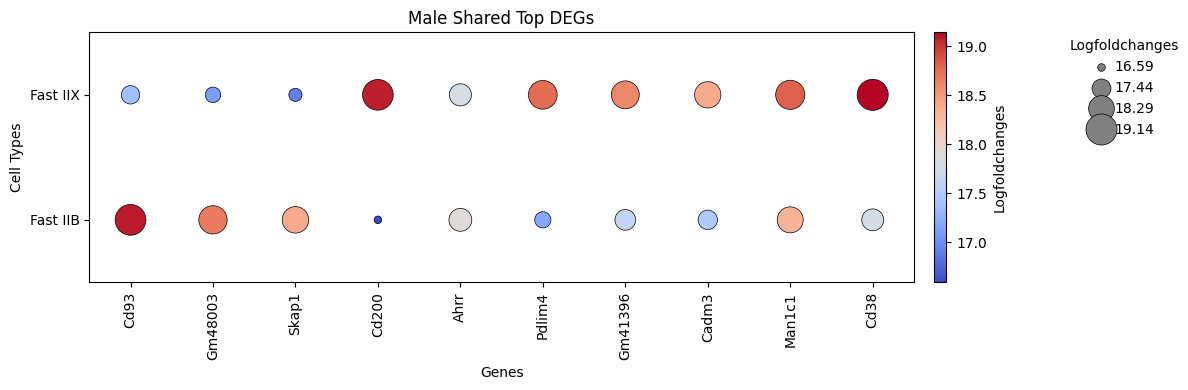

In [45]:
# male
fig_male_dotplot, plot_df = pgl.plot_top_intersecting_genes_dotplot(
    male_top10_genes,
    labels=[
        "Fast IIX",
        "Fast IIB"
    ],
    gene_col="names",
    score_col_prefix="logfoldchanges",
    cmap="coolwarm",
    title="Male Shared Top DEGs"
)

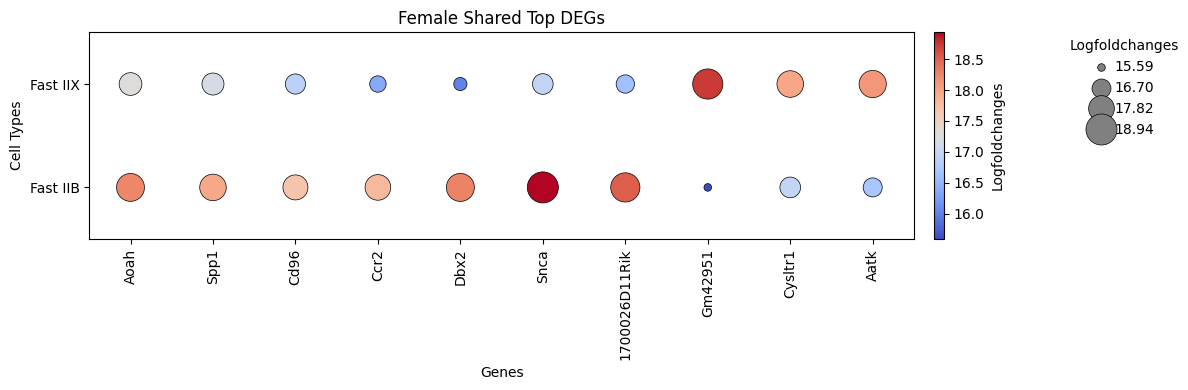

In [46]:
# female
fig_female_dotplot, plot_df = pgl.plot_top_intersecting_genes_dotplot(
    female_top10_genes,
    labels=[
        "Fast IIX",
        "Fast IIB"
    ],
    gene_col="names",
    score_col_prefix="logfoldchanges",
    cmap="coolwarm",
    title="Female Shared Top DEGs"
)

# Save As PNG

In [47]:
# # combine and save as png
# SAVE_PATH = f"Output/Top_DEGs_M_F_IIX_IIB_PNG.png"
# pgl.combine_two_figures(fig_male_dotplot, 
#                         fig_female_dotplot,
#                         layout="vertical",
#                         save_path=SAVE_PATH)

# Save As SVG

In [48]:
from pathlib import Path

# output folder
output_dir = Path("Output")
output_dir.mkdir(parents=True, exist_ok=True)

# figures to save separately
figures_to_save = {
    "Male_Dotplot": fig_male_dotplot,
    "Female_Dotplot": fig_female_dotplot
}

# save each figure as svg and png
for plot_type, fig in figures_to_save.items():

    # create output paths
    svg_path = output_dir / f"Top_DEGs_M_F_IIX_IIB_{plot_type}_SVG.svg"
    png_path = output_dir / f"Top_DEGs_M_F_IIX_IIB_{plot_type}_PNG.png"

    # save editable svg
    pgl.save_editable_svg(
        fig=fig,
        output_path=svg_path
    )

    # save png
    pgl.save_fig_as_png(
        fig=fig,
        output_path=png_path
    )

    print(f"saved: {svg_path}")
    print(f"saved: {png_path}")

saved: Output/Top_DEGs_M_F_IIX_IIB_Male_Dotplot_SVG.svg
saved: Output/Top_DEGs_M_F_IIX_IIB_Male_Dotplot_PNG.png
saved: Output/Top_DEGs_M_F_IIX_IIB_Female_Dotplot_SVG.svg
saved: Output/Top_DEGs_M_F_IIX_IIB_Female_Dotplot_PNG.png
